In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("C://Users//Admin//Downloads//employee_salary_prediction.csv")

In [5]:
df.head()

,Age,Gender,Education,City,Department,JobRole,Experience,PreviousSalary,Projects,WorkingHours,Salary
0,27.0,Female,Bachelor's,Mumbai,HR,Backend Developer,1.7,57644.0,5.0,8.8,100531.0
1,40.0,Female,Bachelor's,Hyderabad,Engineering,ML Engineer,6.0,96154.0,5.0,9.1,141992.0
2,49.0,Male,Bachelor's,Chennai,Marketing,Marketing Executive,13.6,130461.0,6.0,7.6,190519.0
3,35.0,Female,Bachelor's,Hyderabad,Data Science,Backend Developer,4.1,65529.0,5.0,NaN,119795.0
4,31.0,Male,Master's,Bangalore,Finance,ML Engineer,2.7,93635.0,5.0,8.3,144991.0


In [6]:
df.tail()

,Age,Gender,Education,City,Department,JobRole,Experience,PreviousSalary,Projects,WorkingHours,Salary
495,31.0,Male,Bachelor's,Mumbai,Engineering,Data Analyst,3.4,80311.0,2.0,8.5,124827.0
496,42.0,Female,Bachelor's,Chennai,Data Science,Backend Developer,10.5,108928.0,7.0,6.5,179904.0
497,36.0,Male,Master's,Delhi,HR,Marketing Executive,7.5,85221.0,0.0,7.9,136970.0
498,27.0,Female,Master's,Bangalore,Engineering,Marketing Executive,4.8,86335.0,2.0,9.2,120525.0
499,49.0,Female,Master's,NaN,NaN,Sales Executive,14.0,145211.0,0.0,11.4,194354.0


In [7]:
df.shape

(500, 11)

In [8]:
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             480 non-null    float64
 1   Gender          485 non-null    object 
 2   Education       475 non-null    object 
 3   City            480 non-null    object 
 4   Department      480 non-null    object 
 5   JobRole         475 non-null    object 
 6   Experience      470 non-null    float64
 7   PreviousSalary  450 non-null    float64
 8   Projects        470 non-null    float64
 9   WorkingHours    475 non-null    float64
 10  Salary          500 non-null    float64
dtypes: float64(6), object(5)
memory usage: 43.1+ KB


,Age,Experience,PreviousSalary,Projects,WorkingHours,Salary
count,480.000000,470.000000,450.000000,470.000000,475.000000,500.000000
mean,35.856250,6.765745,92995.228889,4.036170,8.575158,141805.162000
std,9.277116,4.434854,32231.952309,1.938492,1.272135,44322.282575
min,21.000000,0.000000,22000.000000,0.000000,6.000000,48255.000000
25%,27.000000,3.100000,66432.750000,3.000000,7.700000,108513.000000
50%,36.000000,6.800000,93995.000000,4.000000,8.500000,142476.000000
75%,44.000000,10.675000,117500.250000,5.000000,9.400000,172501.250000
max,50.000000,16.600000,250000.000000,10.000000,16.000000,400000.000000


In [9]:
df.describe()

,Age,Experience,PreviousSalary,Projects,WorkingHours,Salary
count,480.000000,470.000000,450.000000,470.000000,475.000000,500.000000
mean,35.856250,6.765745,92995.228889,4.036170,8.575158,141805.162000
std,9.277116,4.434854,32231.952309,1.938492,1.272135,44322.282575
min,21.000000,0.000000,22000.000000,0.000000,6.000000,48255.000000
25%,27.000000,3.100000,66432.750000,3.000000,7.700000,108513.000000
50%,36.000000,6.800000,93995.000000,4.000000,8.500000,142476.000000
75%,44.000000,10.675000,117500.250000,5.000000,9.400000,172501.250000
max,50.000000,16.600000,250000.000000,10.000000,16.000000,400000.000000


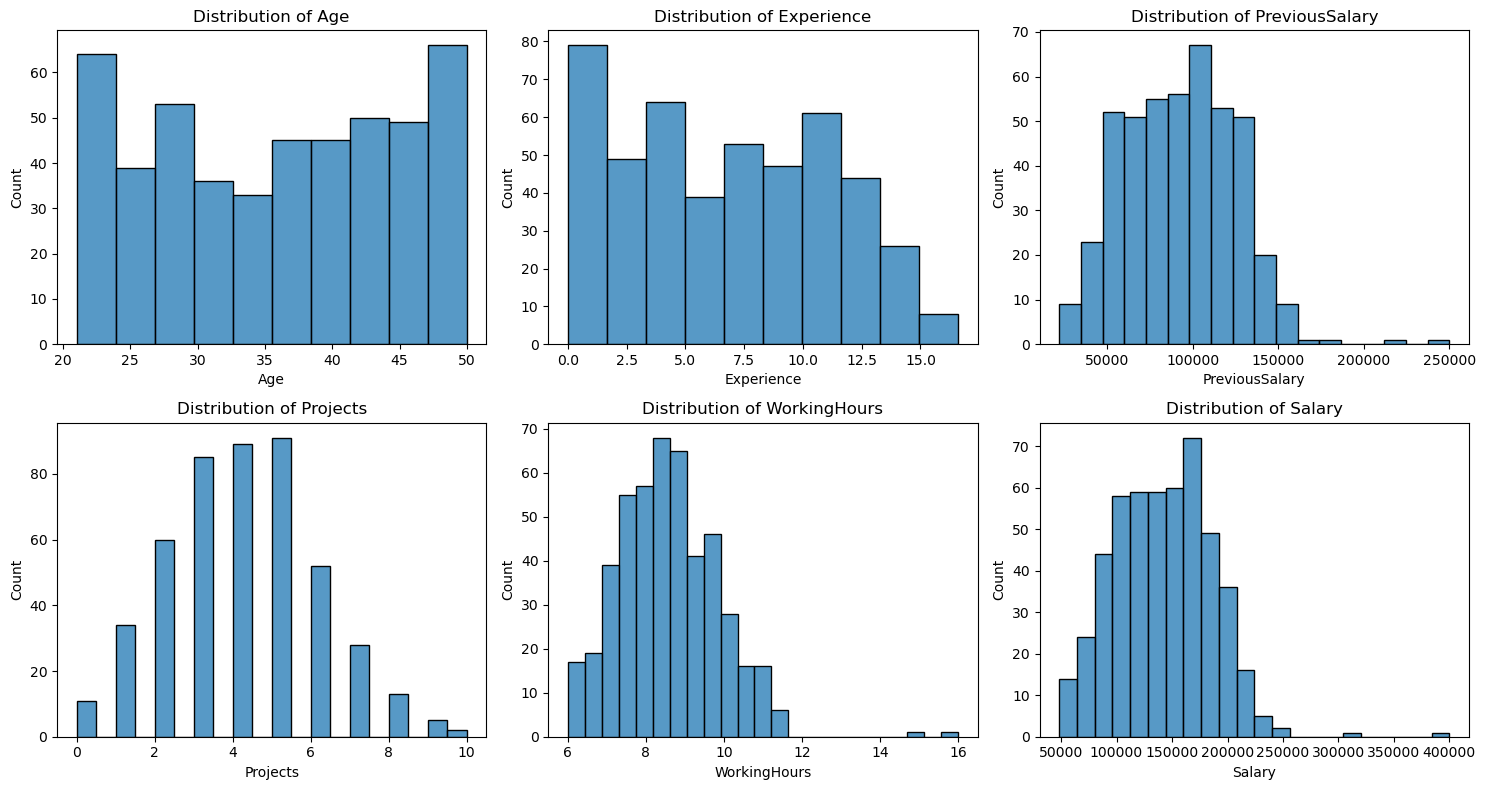

In [10]:
cols = ['Age', 'Experience', 'PreviousSalary', 'Projects', 'WorkingHours', 'Salary']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for i , col in enumerate(cols):
    sns.histplot(data=df, x = col, ax=axes.flat[i])
    axes.flat[i].set_title(f'Distribution of {col}')
#hide the unused 6th subplot
#axes.flat[7].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
cols = ['Gender', 'City', 'Education', 'Department', 'JobRole']
for i in cols:
    print(f"\n{i}:")
    print(df[i].value_counts())


Gender:
Gender
Female    243
Male      233
Other       9
Name: count, dtype: int64

City:
City
Mumbai       92
Hyderabad    90
Bangalore    84
Chennai      74
Pune         74
Delhi        66
Name: count, dtype: int64

Education:
Education
Bachelor's     231
Master's       150
High School     57
PhD             37
Name: count, dtype: int64

Department:
Department
Data Science    91
Marketing       84
HR              79
Sales           79
Finance         74
Engineering     73
Name: count, dtype: int64

JobRole:
JobRole
Data Analyst           80
Software Engineer      61
ML Engineer            59
Marketing Executive    58
Financial Analyst      58
HR Executive           56
Sales Executive        53
Backend Developer      50
Name: count, dtype: int64


In [12]:
cols = ["Gender", "City", "Education", "Department", "JobRole"]
for col in cols:
    print(f"\n{col}:")
    print(df[col].isnull().sum())


Gender:
15

City:
20

Education:
25

Department:
20

JobRole:
25


In [13]:
num_cols =["Age", "Experience", "PreviousSalary", "Projects", "WorkingHours","Salary"]
for col in num_cols:
    print(f"\n{col}:")
    print(df[col].isnull().sum())
    


Age:
20

Experience:
30

PreviousSalary:
50

Projects:
30

WorkingHours:
25

Salary:
0


In [14]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})
missing_table

,Missing Count,Missing %
Age,20,4.0
Gender,15,3.0
Education,25,5.0
City,20,4.0
Department,20,4.0
JobRole,25,5.0
Experience,30,6.0
PreviousSalary,50,10.0
Projects,30,6.0
WorkingHours,25,5.0


In [15]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
X_train.shape
X_test.shape

(100, 10)

In [41]:
y_train.shape
y_test.shape

(100,)

In [18]:
num_cols = [
    'Age',
    'Experience',
    'PreviousSalary',
    'Projects',
    'WorkingHours'
]

cat_cols = [
    'Gender',
    'City',
    'Education',
    'Department',
    'JobRole'
]

In [19]:
num_imputer = SimpleImputer(strategy = 'median')
X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])

In [20]:
X_train_num

array([[2.50000e+01, 1.00000e-01, 5.31960e+04, 5.00000e+00, 9.60000e+00],
       [4.10000e+01, 1.02000e+01, 1.06553e+05, 5.00000e+00, 9.00000e+00],
       [2.30000e+01, 2.10000e+00, 4.46550e+04, 6.00000e+00, 6.80000e+00],
       ...,
       [4.60000e+01, 1.23000e+01, 1.21110e+05, 4.00000e+00, 1.13000e+01],
       [3.60000e+01, 6.35000e+00, 5.16330e+04, 2.00000e+00, 8.60000e+00],
       [2.40000e+01, 4.00000e-01, 4.43390e+04, 3.00000e+00, 1.04000e+01]],
      shape=(400, 5))

In [21]:
X_test_num

array([[4.70000e+01, 1.26000e+01, 1.35987e+05, 6.00000e+00, 7.90000e+00],
       [4.80000e+01, 1.02000e+01, 9.99100e+04, 5.00000e+00, 6.20000e+00],
       [2.10000e+01, 6.35000e+00, 4.91520e+04, 7.00000e+00, 8.60000e+00],
       [2.80000e+01, 4.90000e+00, 8.23930e+04, 4.00000e+00, 7.90000e+00],
       [3.60000e+01, 6.30000e+00, 8.23590e+04, 5.00000e+00, 7.50000e+00],
       [3.80000e+01, 1.10000e+01, 1.23216e+05, 2.00000e+00, 8.10000e+00],
       [3.10000e+01, 6.35000e+00, 7.01640e+04, 4.00000e+00, 8.50000e+00],
       [4.80000e+01, 1.14000e+01, 1.11622e+05, 4.00000e+00, 9.00000e+00],
       [2.90000e+01, 4.40000e+00, 7.84190e+04, 3.00000e+00, 9.20000e+00],
       [5.00000e+01, 1.32000e+01, 1.26907e+05, 5.00000e+00, 1.08000e+01],
       [4.60000e+01, 1.06000e+01, 1.07140e+05, 4.00000e+00, 6.70000e+00],
       [4.00000e+01, 1.06000e+01, 1.26221e+05, 4.00000e+00, 8.60000e+00],
       [4.10000e+01, 6.50000e+00, 8.35050e+04, 4.00000e+00, 8.00000e+00],
       [2.40000e+01, 2.10000e+00, 5.91

In [22]:
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
X_test_cat = cat_imputer.transform(X_test[cat_cols])

In [23]:
X_train_cat

array([['Male', 'Mumbai', "Bachelor's", 'Data Science',
        'Financial Analyst'],
       ['Female', 'Delhi', "Master's", 'Finance', 'Sales Executive'],
       ['Female', 'Chennai', "Bachelor's", 'Data Science',
        'Data Analyst'],
       ...,
       ['Male', 'Hyderabad', "Master's", 'Marketing',
        'Marketing Executive'],
       ['Male', 'Chennai', "Master's", 'Sales', 'Sales Executive'],
       ['Male', 'Mumbai', "Master's", 'Marketing', 'Financial Analyst']],
      shape=(400, 5), dtype=object)

In [24]:
X_test_cat

array([['Female', 'Bangalore', "Bachelor's", 'Data Science',
        'Backend Developer'],
       ['Male', 'Chennai', "Master's", 'Sales', 'Financial Analyst'],
       ['Female', 'Mumbai', "Bachelor's", 'Sales', 'Data Analyst'],
       ['Male', 'Mumbai', "Bachelor's", 'Engineering', 'ML Engineer'],
       ['Male', 'Hyderabad', "Bachelor's", 'Finance',
        'Financial Analyst'],
       ['Female', 'Hyderabad', "Master's", 'Finance', 'ML Engineer'],
       ['Female', 'Pune', "Master's", 'Engineering', 'Data Analyst'],
       ['Female', 'Chennai', "Bachelor's", 'Engineering', 'Data Analyst'],
       ['Female', 'Chennai', "Bachelor's", 'Data Science',
        'Sales Executive'],
       ['Male', 'Hyderabad', 'High School', 'HR', 'Marketing Executive'],
       ['Male', 'Hyderabad', 'High School', 'Data Science',
        'HR Executive'],
       ['Female', 'Chennai', "Master's", 'Finance', 'Data Analyst'],
       ['Male', 'Hyderabad', 'High School', 'Data Science',
        'Financial Analyst

In [25]:
print('Numerical missing values:')
print(np.isnan(X_train_num).sum())
print('\n Categorical missing values:')
print(pd.isnull(X_train_cat).sum())

Numerical missing values:
0

 Categorical missing values:
0


In [26]:
knn_imputer = KNNImputer(n_neighbors = 5)
X_train_knn = knn_imputer.fit_transform(X_train[num_cols])
X_test_knn = knn_imputer.transform(X_test[num_cols])

In [27]:
print(np.isnan(X_train_knn).sum())
print(np.isnan(X_test_knn).sum())

0
0


In [28]:
missing_idx = X_train['PreviousSalary'].isnull()
comparison = pd.DataFrame({
    'Age':X_train.loc[missing_idx, 'Age'],
    'Experience':X_train.loc[missing_idx, 'Experience'],
    'Projects' : X_train.loc[missing_idx, 'Projects'],
    'WorkingHours':X_train.loc[missing_idx, 'WorkingHours'],
    'Median_Imputed':X_train_num[missing_idx, num_cols.index('PreviousSalary')],
    'KNN_Imputed': X_train_knn[missing_idx, num_cols.index('PreviousSalary')]
})
comparison.head(10)

,Age,Experience,Projects,WorkingHours,Median_Imputed,KNN_Imputed
132,27.0,3.0,4.0,7.4,91964.5,64245.8
357,50.0,NaN,3.0,8.7,91964.5,118898.6
157,22.0,1.3,5.0,7.4,91964.5,46143.4
114,36.0,7.1,5.0,6.0,91964.5,89343.0
144,23.0,3.3,2.0,8.1,91964.5,100706.0
369,23.0,3.2,7.0,NaN,91964.5,52030.2
67,46.0,13.0,2.0,10.4,91964.5,133483.2
493,21.0,0.0,NaN,11.0,91964.5,50992.8
245,28.0,1.1,7.0,8.4,91964.5,50015.4
358,32.0,5.9,4.0,8.2,91964.5,79616.0


In [32]:
Q1 = X_train[num_cols].quantile(0.25)
Q2 = X_train[num_cols].quantile(0.75)
IQR = Q2 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q2 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

outlier_count = (
    (X_train[num_cols] < lower_bound) |
    (X_train[num_cols] > upper_bound)
).sum()
outlier_count

Age                  1.875
Experience          -8.400
PreviousSalary   -8096.000
Projects             0.000
WorkingHours         5.150
dtype: float64
Age                   68.875
Experience            21.800
PreviousSalary    188248.000
Projects               8.000
WorkingHours          11.950
dtype: float64


Age               0
Experience        0
PreviousSalary    2
Projects          6
WorkingHours      1
dtype: int64

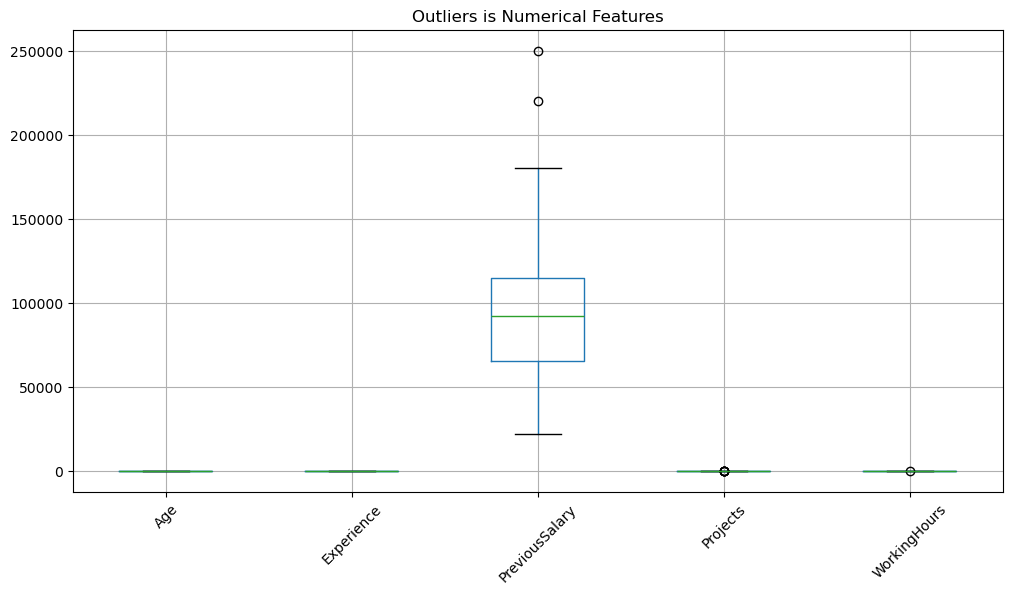

In [33]:
X_train[num_cols].boxplot(figsize = (12,6))
plt.title("Outliers is Numerical Features")
plt.xticks(rotation = 45)
plt.show()

In [34]:
encoder = OneHotEncoder(handle_unknown = "ignore")
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [35]:
encoder.fit_transform(X_train[cat_cols])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2000 stored elements and shape (400, 32)>

In [36]:
encoder.transform(X_test[cat_cols])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 500 stored elements and shape (100, 32)>

In [38]:
numeric_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = "median")),
    ("scaler" , StandardScaler())
])
print(numeric_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [39]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])

In [43]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [45]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [46]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
y_pred = model.predict(X_test)

In [49]:
comparision = pd.DataFrame({
    "Actual Salary" : y_test,
    "Predicted Salary": y_pred
})
comparision.head(10)

,Actual Salary,Predicted Salary
361,200283.0,206350.736550
73,181641.0,165261.260168
374,108697.0,108031.183761
155,144020.0,133682.866993
104,121935.0,131769.458721
394,202283.0,185667.699197
377,105072.0,137055.324924
124,157605.0,183380.073229
68,99432.0,94946.239940
450,161923.0,186128.981719
